# Quantile Mapping — Model Update Stability Study

Quantile mapping is a technique for keeping a fixed-threshold alerting rule
stable even as the underlying classifier is retrained or replaced. This
notebook demonstrates the idea end to end, for ONE BAF variant and ONE
seed, on the public **Bank Account Fraud (BAF)** dataset (Jesus et al.,
NeurIPS 2022 Datasets & Benchmarks; see the citation section at the end).

For the full robustness check across multiple BAF variants and multiple
random seeds (not just the single walkthrough run here), see
`scripts/run_experiment.py --variant ... --seeds ...` and the resulting
`results/summary_all_variants.json` -- the README's headline numbers are
drawn from that multi-variant/multi-seed sweep, not from this notebook's
single run.

**The problem.** A downstream system flags an event whenever a model's
score exceeds some fixed threshold. If the model producing that score is
retrained or replaced, its raw score distribution shifts -- so the same
fixed threshold now yields a different alert rate, even if the model's
actual discriminative quality hasn't changed. Quantile mapping fixes this
by remapping raw scores onto a fixed target population, so a fixed
threshold keeps yielding (approximately) the same alert rate regardless of
which model produced the underlying score.

**Design.** An "old" and a "new" model are trained once, up front, on the
**same** training window, with a wide hyperparameter gap -- a shallow,
under-tuned "legacy" model vs. a properly tuned, higher-capacity one, a
genuine model replacement via capacity/tuning (not via training recency),
so neither model has a home-turf advantage over the other when their
initial mappings are fit. The gap needs to be wide: see
`scripts/check_model_divergence.py`, which computes the old/new score
correlation directly and is what the README's "~0.7 correlation" claim is
reproduced from. The two models are then frozen and never retrained
again. p1/p1_5's quantile mapping is ALSO fit once, on the single month
right after training, and never revisited -- a production mapping that
stops being maintained once the old model is retired. Every later month
(strictly after training and the initial mapping-fit month) becomes one
walk-forward **evaluation step**: p2's mapping is refit fresh at each
step on just the month immediately before it; custom's mapping is refit
fresh at each step on an expanding window starting at the LAST training
month; p1's model+mapping and p1_5's mapping never change again.

**Predictor variants, evaluated at every step:**

- `p1` -- old model, quantile mapping fit once (on the month right after training), never refit.
- `p1_5` -- new model, paired with p1's (old model's, fixed) quantile mapping -- the worst-case combination: a different model than the one the mapping was calibrated on, and that mapping is never refit either.
- `p2` -- new model, with a quantile mapping refit every step on just the single nearest prior month.
- `custom` -- new model, with a quantile mapping refit every step on an expanding window starting at the last training month -- a distinct, wider "kept fresh" policy than p2's, always at least 2 months wide (so it never numerically coincides with p2, even at the first evaluation step).
- `default` -- new model, with its OWN dedicated mapping, fit once (on a month distinct from p1/p1_5's, p2's, and custom's) and never revisited -- "we set up a mapping for the new model at launch and never built a process to refresh it", as distinct from p1_5's "we swapped models but forgot to refresh the OLD model's mapping".
- `raw` -- new model's scores with no mapping applied at all.


In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import display, Markdown

from muse.data import load_variant
from muse.experiment import run_walk_forward_experiment
from muse.plotting import plot_relative_error_boxplot, set_paper_style

set_paper_style()

## Parameters

In [ ]:
VARIANT = "Base"
DATA_DIR = None  # None -> download via kagglehub automatically

BETA_OLD = 0.05
BETA_NEW = 0.50
N_ESTIMATORS_OLD = 20
N_ESTIMATORS_NEW = 500
MAX_DEPTH_OLD = 1
MAX_DEPTH_NEW = 10
NUM_LEAVES_OLD = 2
NUM_LEAVES_NEW = 128
LEARNING_RATE_OLD = 0.5
LEARNING_RATE_NEW = 0.03
SEED = 0

FIXED_EDGE = 0.6  # for the fixed-edge alert-rate view
MODEL_UPDATE_PREDICTORS = ["p1", "p1_5", "p2"]
CALIBRATION_PREDICTORS = ["raw", "default", "custom"]

OUTPUT_DIR = Path("results")  # this notebook's own output dir; kept separate from scripts/run_experiment.py's results/<variant>/ tree


## §1 Load data & run the walk-forward experiment

In [3]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = load_variant(VARIANT, data_dir=DATA_DIR)
months = sorted(int(m) for m in df["month"].unique())
model_train_months = months[:2]
mapping_fit_month = max(model_train_months) + 1
eval_months = [m for m in months if m > mapping_fit_month]
print(f"BAF variant: {VARIANT} | {len(df)} rows | months {months}")
print(f"old_model trains on {model_train_months} (beta={BETA_OLD}, n_estimators={N_ESTIMATORS_OLD}, "
      f"max_depth={MAX_DEPTH_OLD}, num_leaves={NUM_LEAVES_OLD}, learning_rate={LEARNING_RATE_OLD})")
print(f"new_model trains on {model_train_months} (beta={BETA_NEW}, n_estimators={N_ESTIMATORS_NEW}, "
      f"max_depth={MAX_DEPTH_NEW}, num_leaves={NUM_LEAVES_NEW}, learning_rate={LEARNING_RATE_NEW})")
print(f"mapping_old/first mapping_new fit on month {mapping_fit_month}")
print(f"walk-forward evaluation steps: {eval_months} ({len(eval_months)} steps)")

rel_err_df = run_walk_forward_experiment(
    df,
    model_train_months=model_train_months,
    eval_months=eval_months,
    beta_old=BETA_OLD,
    beta_new=BETA_NEW,
    n_estimators_old=N_ESTIMATORS_OLD,
    n_estimators_new=N_ESTIMATORS_NEW,
    max_depth_old=MAX_DEPTH_OLD,
    max_depth_new=MAX_DEPTH_NEW,
    num_leaves_old=NUM_LEAVES_OLD,
    num_leaves_new=NUM_LEAVES_NEW,
    learning_rate_old=LEARNING_RATE_OLD,
    learning_rate_new=LEARNING_RATE_NEW,
    seed=SEED,
)
rel_err_df.to_csv(OUTPUT_DIR / "relative_error.csv", index=False)

eval_steps = rel_err_df[["point_idx", "mapping_new_fit_month", "eval_month"]].drop_duplicates()
display(eval_steps)


BAF variant: Base | 1000000 rows | months [0, 1, 2, 3, 4, 5, 6, 7]
old_model trains on [0, 1] (beta=0.05, n_estimators=20, max_depth=1, num_leaves=2, learning_rate=0.5)
new_model trains on [0, 1] (beta=0.5, n_estimators=500, max_depth=10, num_leaves=128, learning_rate=0.03)
mapping_old/first mapping_new fit on month 2
walk-forward evaluation steps: [3, 4, 5, 6, 7] (5 steps)


,point_idx,mapping_new_fit_month,eval_month
0,0,2,3
24,1,3,4
48,2,4,5
72,3,5,6
96,4,6,7


## §2 Alert-rate relative error, per predictor

One box per predictor at each fixed-threshold edge, aggregated across
every walk-forward step. If quantile mapping is doing its job, `p2`
should stay close to the target throughout; `p1`/`p1_5` (mapping fixed
at the swap point, never refit again) should drift further from it.


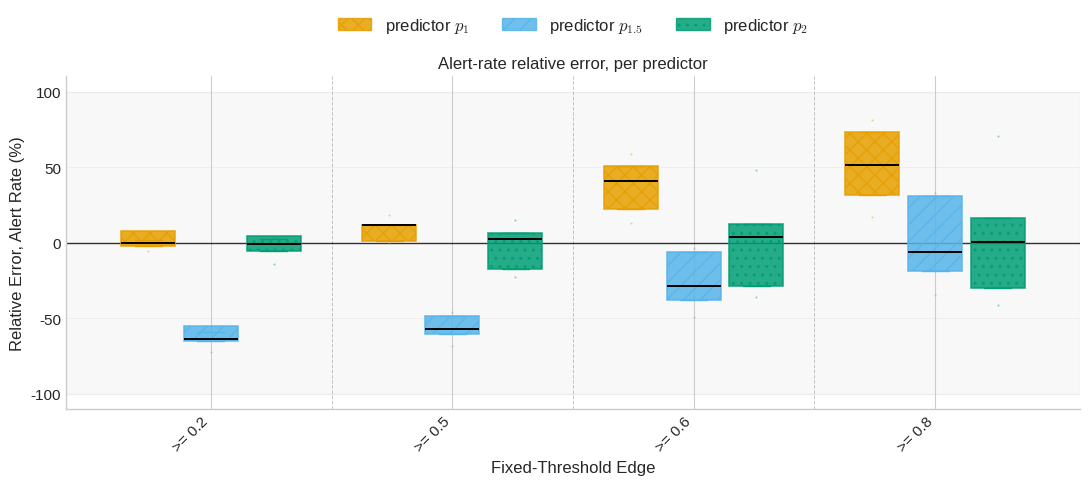

In [4]:
fig_box = plot_relative_error_boxplot(rel_err_df, predictors=MODEL_UPDATE_PREDICTORS)
fig_box.savefig(OUTPUT_DIR / "relative_error_boxplot.pdf")

## §3 Calibration-only view (model held fixed)

`raw` (no mapping), `default` (its own dedicated mapping, fit once before
the walk-forward starts and never revisited), and `custom` (mapping
refit at every step) all use the SAME new model at every step -- so this
isolates how much of the instability is a calibration/refit-cadence
effect on its own, separate from the model swap. `default`'s mapping is
fit on a month distinct from `p1`/`p1_5`'s `mapping_old` and from
`p2`/`custom`'s per-step mappings, so it never numerically coincides with
any of them, even at the first evaluation step.


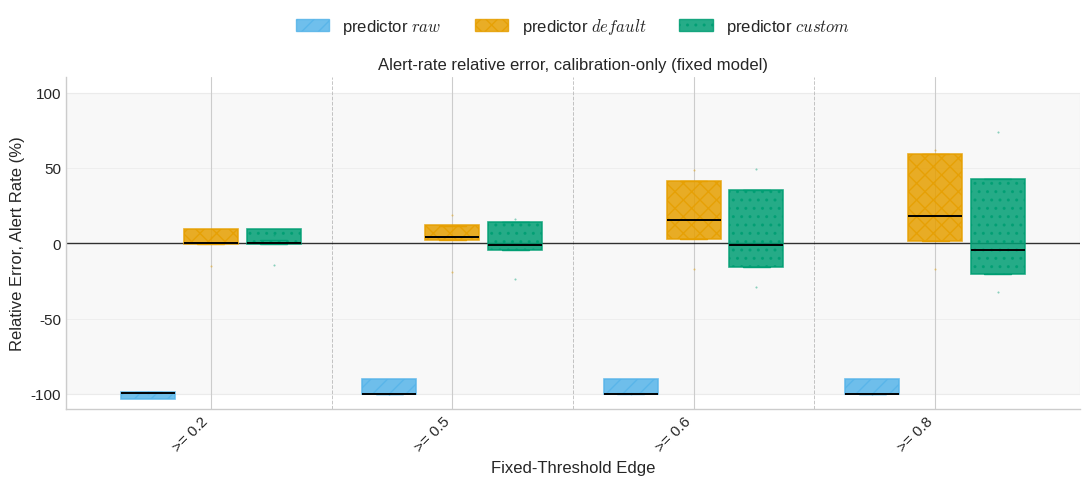

In [5]:
fig_box_calib = plot_relative_error_boxplot(
    rel_err_df, predictors=CALIBRATION_PREDICTORS,
    title="Alert-rate relative error, calibration-only (fixed model)",
)
fig_box_calib.savefig(OUTPUT_DIR / "relative_error_boxplot_calibration.pdf")

## §4 Median relative error per threshold edge, per predictor


In [6]:
median_tbl = (
    rel_err_df.groupby(["predictor", "bin_label"])["relative_error_pct"]
    .median()
    .unstack("predictor")
    .reindex(columns=MODEL_UPDATE_PREDICTORS + CALIBRATION_PREDICTORS)
)
display(median_tbl.round(1))

predictor,p1,p1_5,p2,raw,default,custom
bin_label,,,,,,
>= 0.2,0.1,-63.5,-0.8,-99.3,0.0,0.0
>= 0.5,11.5,-57.0,2.2,-99.9,4.4,-1.2
>= 0.6,40.7,-28.2,3.8,-99.7,15.6,-1.3
>= 0.8,51.4,-6.0,0.7,-99.9,17.9,-4.2


## §5 Summary

In [7]:
median_abs_err = (
    rel_err_df.groupby("predictor")["relative_error_pct"]
    .apply(lambda s: s.abs().median())
    .to_dict()
)

summary = {
    "variant": VARIANT,
    "months": months,
    "model_train_months": model_train_months,
    "mapping_fit_month": mapping_fit_month,
    "n_eval_steps": int(rel_err_df["point_idx"].nunique()),
    "beta_old": BETA_OLD,
    "beta_new": BETA_NEW,
    "n_estimators_old": N_ESTIMATORS_OLD,
    "n_estimators_new": N_ESTIMATORS_NEW,
    "max_depth_old": MAX_DEPTH_OLD,
    "max_depth_new": MAX_DEPTH_NEW,
    "num_leaves_old": NUM_LEAVES_OLD,
    "num_leaves_new": NUM_LEAVES_NEW,
    "learning_rate_old": LEARNING_RATE_OLD,
    "learning_rate_new": LEARNING_RATE_NEW,
    "fixed_edge": FIXED_EDGE,
    "median_abs_relative_error_pct_by_predictor": median_abs_err,
}
with open(OUTPUT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

p1_err = median_abs_err["p1"]
p15_err = median_abs_err["p1_5"]
p2_err = median_abs_err["p2"]
n_steps = summary["n_eval_steps"]

text = (
    f"- **p1** median |relative error|, across {n_steps} evaluation steps: {p1_err:.1f}%\n"
    f"- **p1_5** (new model + p1's stale mapping) median |relative error|: {p15_err:.1f}%\n"
    f"- **p2** (new model + mapping refit every step) median |relative error|: {p2_err:.1f}%\n\n"
    "p1_5 pairs the new model with a mapping that was never calibrated for "
    "it in the first place (it was fit on the old model's scores) and is "
    "never refit either -- the worst-case combination. Looking at the "
    "median error per threshold edge (not just the aggregate) makes this "
    "clear: p1 stays tightest around zero throughout, p2 sits close to it "
    "in most edges, and p1_5 is consistently the most extreme of the "
    "three at almost every edge."
)
display(Markdown(text))


- **p1** median |relative error|, across 5 evaluation steps: 15.0%
- **p1_5** (new model + p1's stale mapping) median |relative error|: 47.1%
- **p2** (new model + mapping refit every step) median |relative error|: 14.4%

p1_5 pairs the new model with a mapping that was never calibrated for it in the first place (it was fit on the old model's scores) and is never refit either -- the worst-case combination. Looking at the median error per threshold edge (not just the aggregate) makes this clear: p1 stays tightest around zero throughout, p2 sits close to it in most edges, and p1_5 is consistently the most extreme of the three at almost every edge.

## Dataset citation

This notebook uses the **Bank Account Fraud (BAF)** dataset suite. See the
"About the dataset" section of the repository README for the full citation
and license terms.